# Python DA Assignment 2 - Data Visualization

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Loading the Taxis Dataset

In [78]:
# Load the taxis dataset
df = sns.load_dataset("taxis")

## 2. Handling Missing Values

In [79]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [80]:
categorical_columns = [
    "payment",
    "pickup_zone",
    "dropoff_zone",
    "pickup_borough",
    "dropoff_borough"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [81]:
df.isnull().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

## 3. Visualizations using Matplotlib/Pandas Plot

### Line Chart

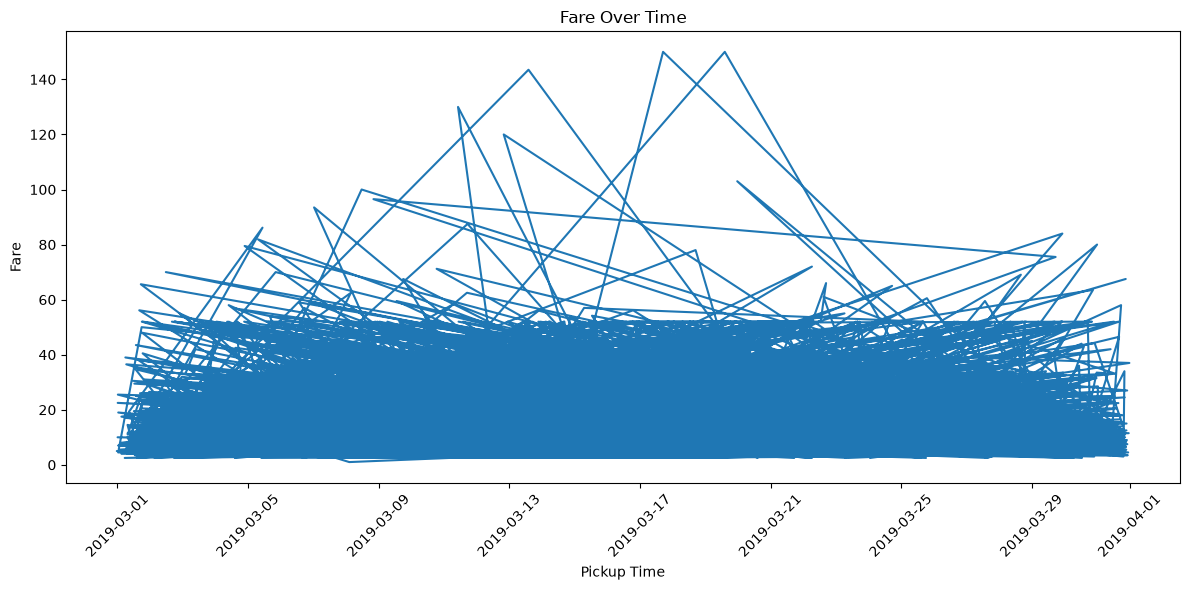

In [82]:
df["pickup"] = pd.to_datetime(df["pickup"])

plt.figure(figsize=(12, 6))
plt.plot(df["pickup"], df["fare"])

plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bar Chart

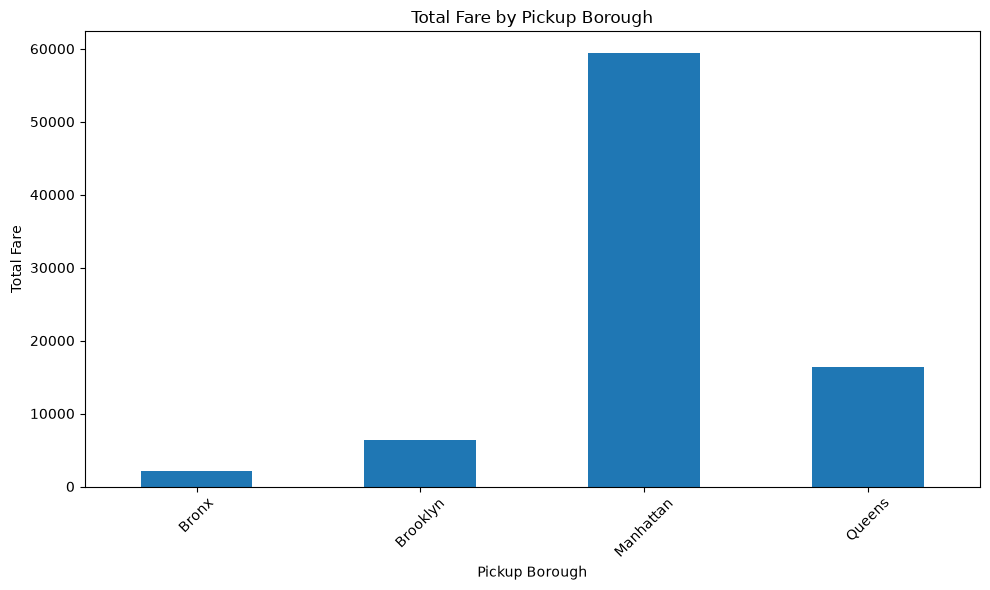

In [83]:
total_fare_by_borough = df.groupby("pickup_borough")["fare"].sum()

total_fare_by_borough.plot(kind="bar", figsize=(10, 6))

plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Pie Chart

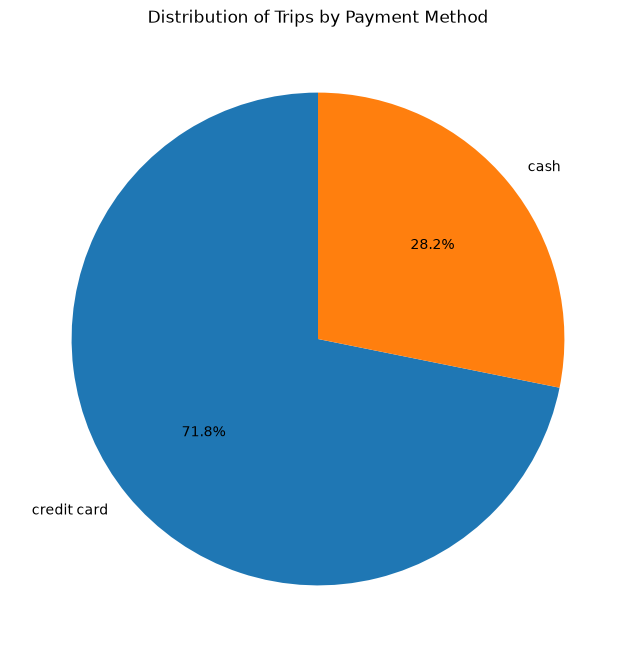

In [84]:
payment_counts = df["payment"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Trips by Payment Method")
plt.show()

### Histogram

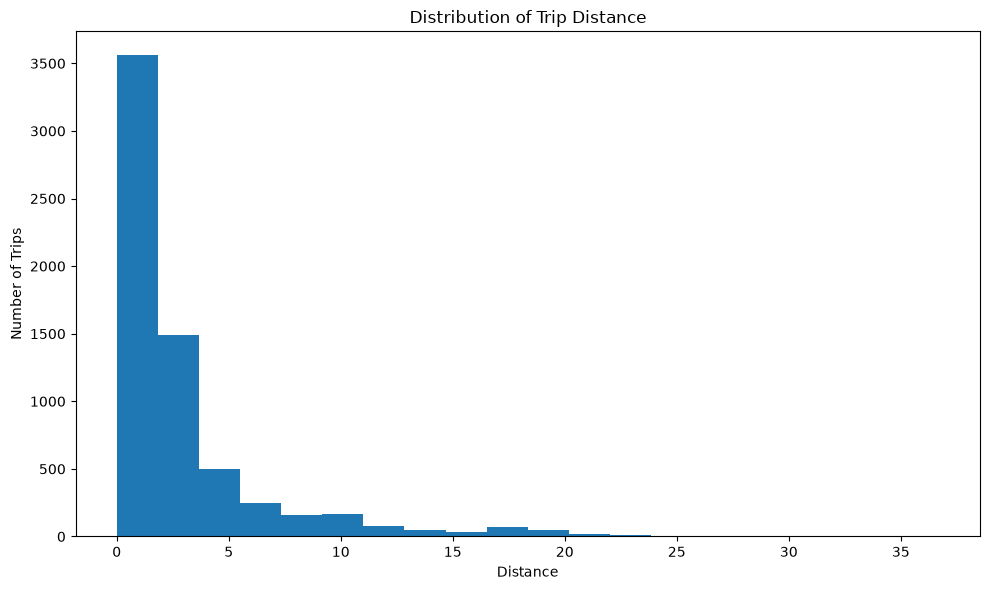

In [85]:
plt.figure(figsize=(10, 6))

plt.hist(df["distance"], bins=20)

plt.title("Distribution of Trip Distance")
plt.xlabel("Distance")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

### Box Plot

<Figure size 1000x600 with 0 Axes>

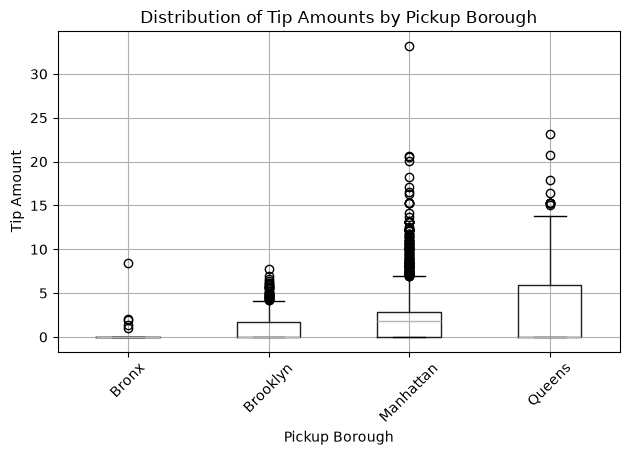

In [86]:
plt.figure(figsize=(10, 6))

df.boxplot(column="tip", by="pickup_borough")

plt.title("Distribution of Tip Amounts by Pickup Borough")
plt.suptitle("")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualizations using Seaborn

### Count Plot

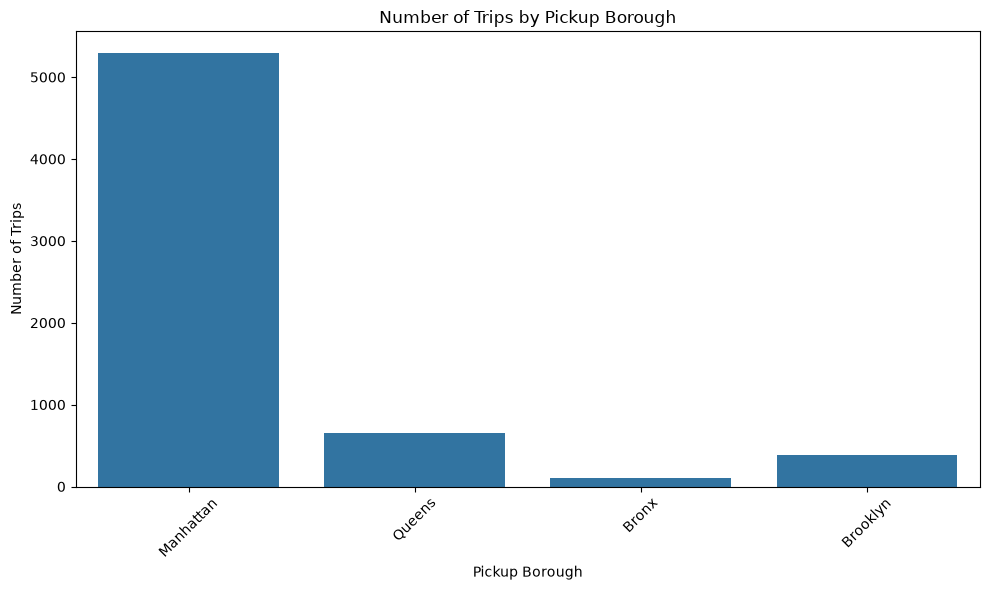

In [87]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="pickup_borough")

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Scatter Plot

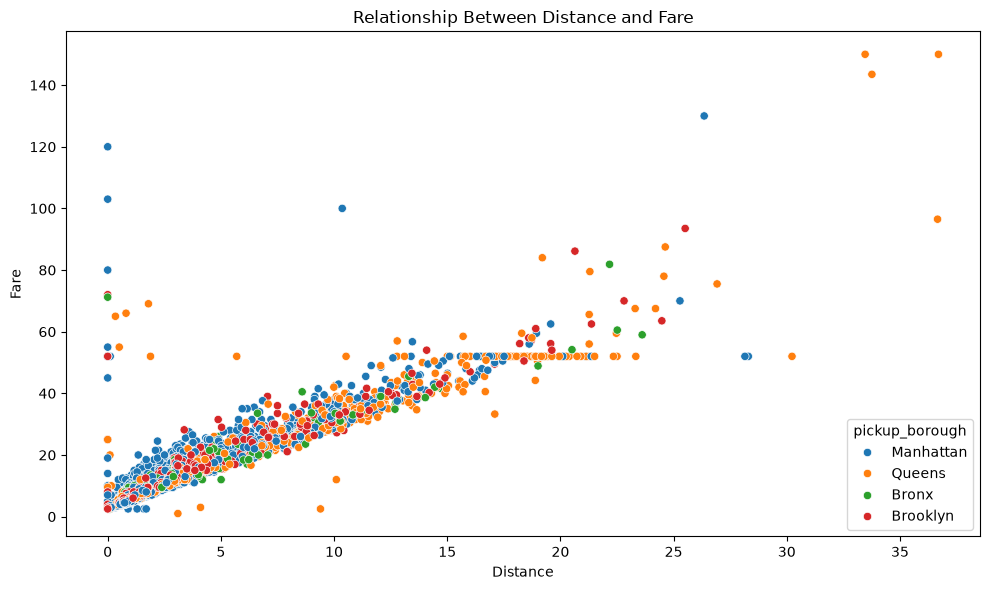

In [88]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough"
)

plt.title("Relationship Between Distance and Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

### Heatmap

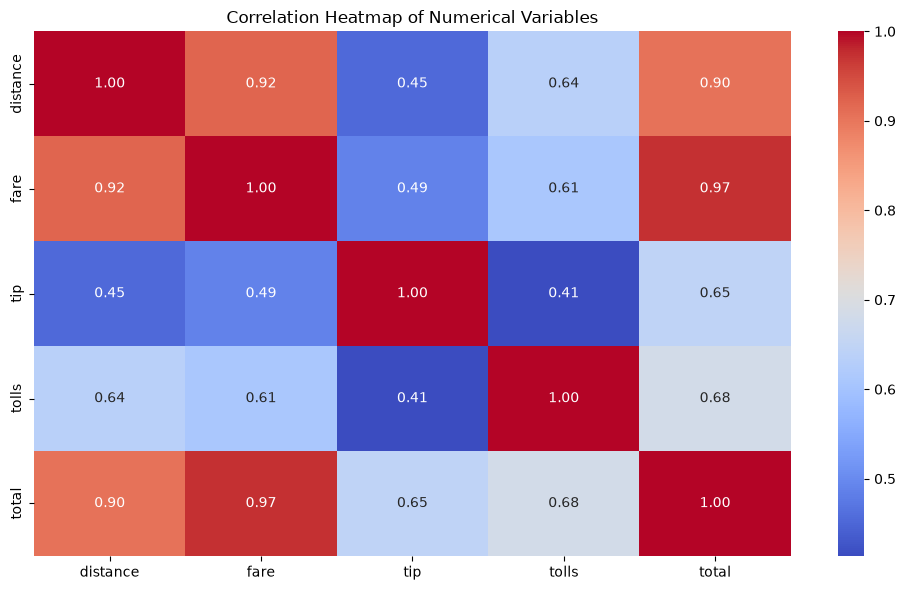

In [89]:
numerical_columns = ["distance", "fare", "tip", "tolls", "total"]

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

### Pair Plot

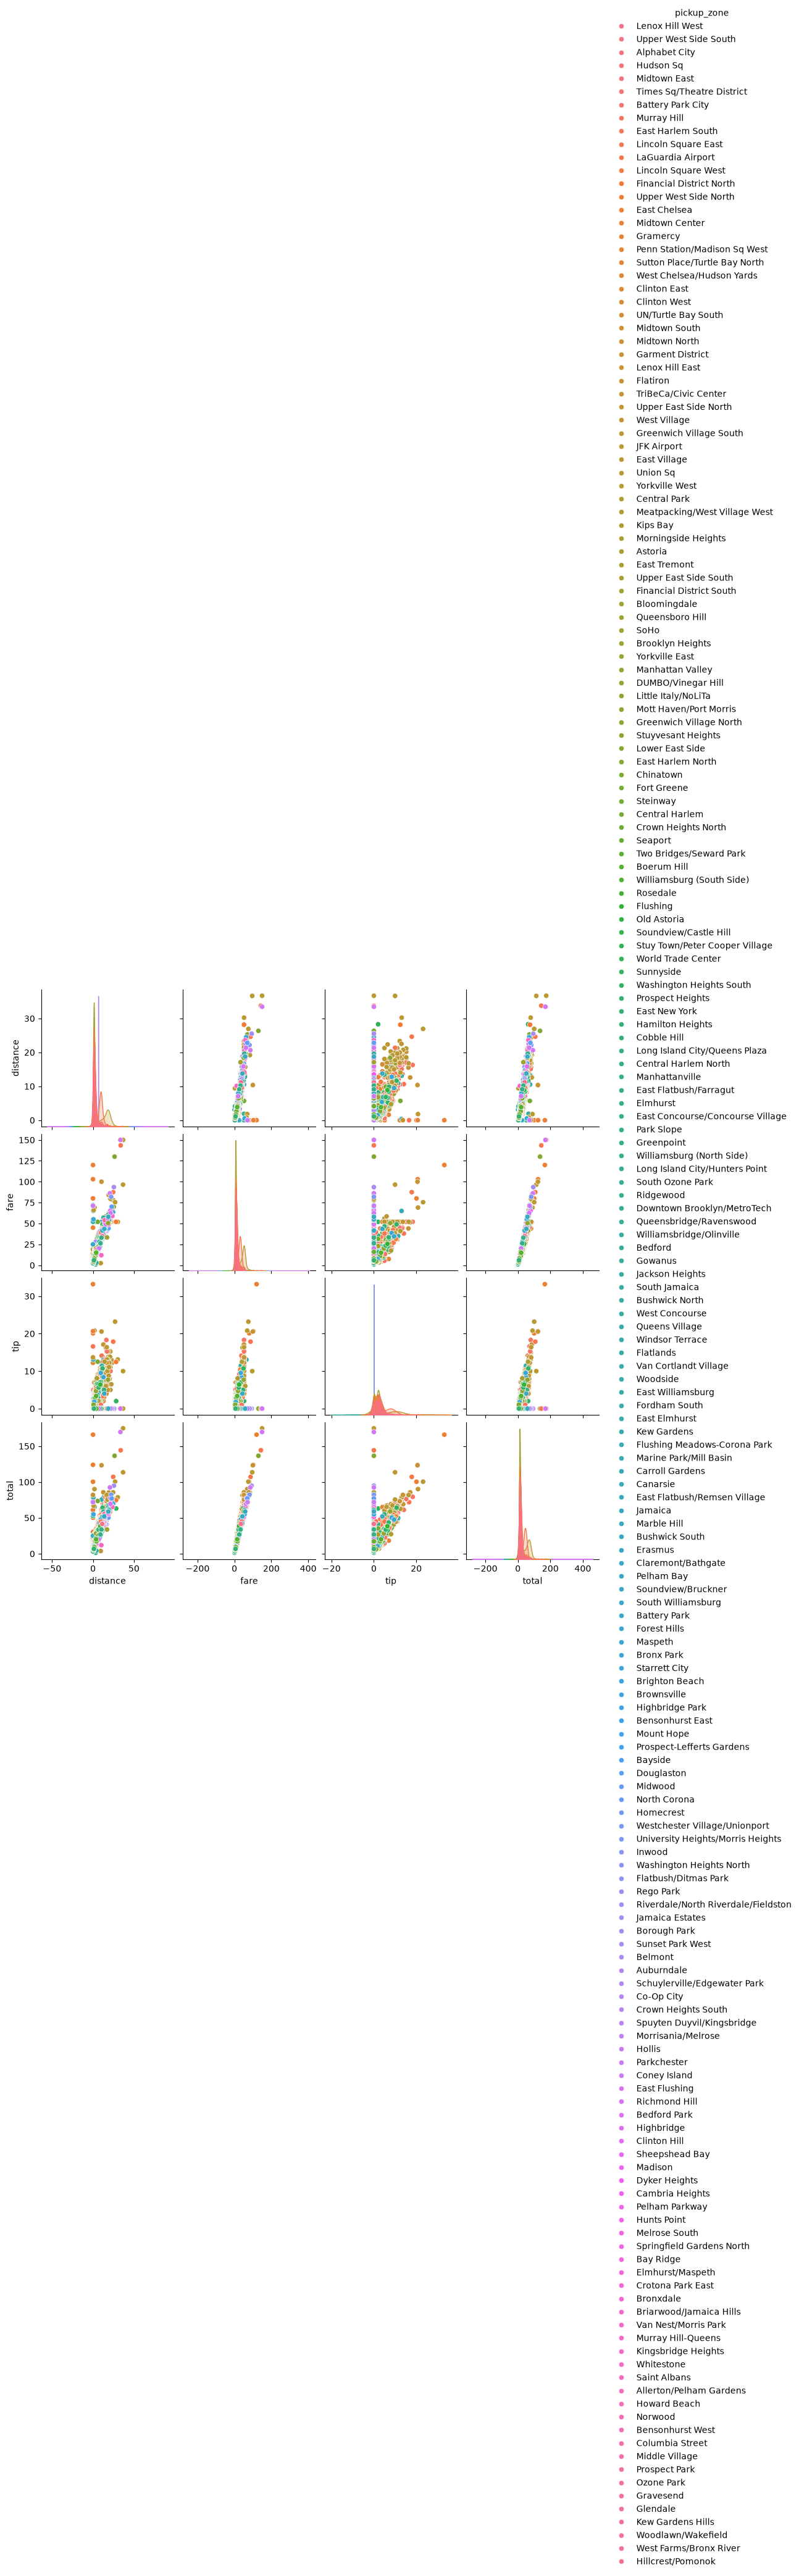

In [90]:
sns.pairplot(
    df,
    vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone"
)

plt.show()

### Violin Plot

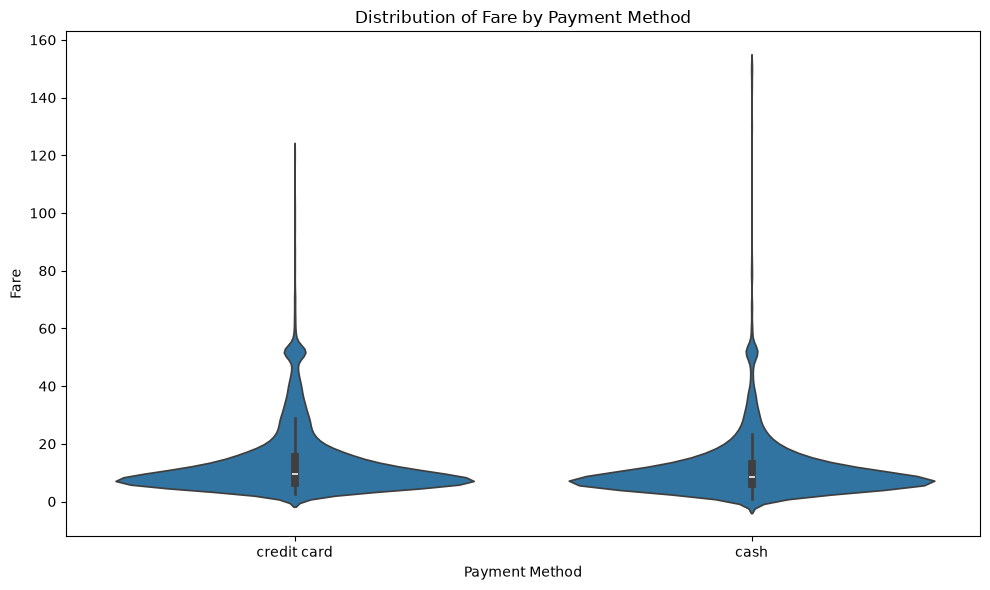

In [91]:
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x="payment", y="fare")

plt.title("Distribution of Fare by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()